In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
airbnb = pd.read_csv("airbnb_final.csv")
poi = pd.read_csv("poi_final.csv")

In [70]:
# printing for visability

print("airbnb", airbnb.shape)
print("poi", poi.shape)

display(airbnb.head())
display(poi.head())

airbnb (33689, 19)
poi (9607, 4)


,listing_id,room_type,latitude,longitude,guests,bedrooms,beds,baths,property_type,neighborhood,month_date,available_days,occupancy,avg_daily_rate,revenue,active,booking_lead_time_avg,length_of_stay_avg,revpar
0,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-03-01,31,0.000,24.4,0.0,False,NaN,NaN,0.000000
1,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-04-01,30,0.000,24.3,0.0,False,NaN,NaN,0.000000
2,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-05-01,26,0.161,24.8,125.0,True,NaN,NaN,4.032258
3,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-06-01,30,0.000,24.7,0.0,True,NaN,NaN,0.000000
4,14948804,private_room,41.40698,2.18241,2.0,1.0,1.0,1.0,Apartment & Condo,Sant Martí,2021-07-01,31,0.000,25.0,0.0,True,NaN,NaN,0.000000


,name,latitude,longitude,category
0,NaN,41.443003,2.206936,attraction
1,NaN,41.449042,2.195413,attraction
2,Ⓐ,41.464660,2.203062,attraction
3,NaN,41.460651,2.177291,attraction
4,NaN,41.448733,2.186346,attraction


In [71]:
# Check airbnb columns and poi category distribution

print(airbnb.columns)
print(poi["category"].value_counts())

Index(['listing_id', 'room_type', 'latitude', 'longitude', 'guests',
       'bedrooms', 'beds', 'baths', 'property_type', 'neighborhood',
       'month_date', 'available_days', 'occupancy', 'avg_daily_rate',
       'revenue', 'active', 'booking_lead_time_avg', 'length_of_stay_avg',
       'revpar'],
      dtype='str')
category
horeca        8712
attraction     721
metro          174
Name: count, dtype: int64


In [72]:
# Converting month_date to datetime

airbnb["month_date"] = pd.to_datetime(airbnb["month_date"])
airbnb.dtypes

listing_id                        int64
room_type                           str
latitude                        float64
longitude                       float64
guests                          float64
bedrooms                        float64
beds                            float64
baths                           float64
property_type                       str
neighborhood                        str
month_date               datetime64[us]
available_days                    int64
occupancy                       float64
avg_daily_rate                  float64
revenue                         float64
active                             bool
booking_lead_time_avg           float64
length_of_stay_avg              float64
revpar                          float64
dtype: object

In [73]:
# Keep only active airbnb listings

df = airbnb[airbnb["active"] == True].copy()

print(df.shape)
print(df["active"].value_counts())

(26915, 19)
active
True    26915
Name: count, dtype: int64


In [74]:
# dropping rows with missing neighborhood values

df_neighborhood = df.dropna(subset=["neighborhood"]).copy()

print(df_neighborhood["neighborhood"].value_counts())

neighborhood
Eixample                 10082
Old Town                  5868
Sants-Montjuïc            2647
Sant Martí                2410
Gràcia                    2064
Sarrià - Sant Gervasi     1446
Horta-Guinardó             755
les Corts                  521
Sant Andreu                429
Nou Barris                 234
Districte II                60
Name: count, dtype: int64


In [75]:
# Grouping by neighborhood and calculating mean

neighborhood_performance = (
    df_neighborhood.groupby("neighborhood")[["occupancy", "avg_daily_rate", "revpar", "revenue"]]
)

neighborhood_performance.mean().round(2)

,occupancy,avg_daily_rate,revpar,revenue
neighborhood,,,,
Districte II,0.76,95.86,71.38,2170.98
Eixample,0.55,227.29,127.56,3886.67
Gràcia,0.57,189.67,109.33,3331.46
Horta-Guinardó,0.56,120.72,65.92,2009.11
Nou Barris,0.36,31.77,13.00,395.35
Old Town,0.48,133.86,62.06,1891.48
Sant Andreu,0.49,187.65,116.53,3551.35
Sant Martí,0.48,142.85,76.13,2320.57
Sants-Montjuïc,0.50,154.95,77.14,2350.78


In [76]:
# Counting unique listings per neighborhood

listing_counts = (
    df_neighborhood.groupby("neighborhood")["listing_id"].nunique()
)

neighborhood_performance = neighborhood_performance.mean().round(2)
neighborhood_performance["listings"] = listing_counts

neighborhood_performance

,occupancy,avg_daily_rate,revpar,revenue,listings
neighborhood,,,,,
Districte II,0.76,95.86,71.38,2170.98,1
Eixample,0.55,227.29,127.56,3886.67,309
Gràcia,0.57,189.67,109.33,3331.46,61
Horta-Guinardó,0.56,120.72,65.92,2009.11,27
Nou Barris,0.36,31.77,13.00,395.35,12
Old Town,0.48,133.86,62.06,1891.48,234
Sant Andreu,0.49,187.65,116.53,3551.35,16
Sant Martí,0.48,142.85,76.13,2320.57,84
Sants-Montjuïc,0.50,154.95,77.14,2350.78,95


##### H1.1 Which neighbourhoods show the best and worst performance in terms of:
    - Occupancy
    - ADR
    - RevPAR
    - Revenue

In [77]:
# best occupancy

neighborhood_performance.sort_values("occupancy", ascending=False)

,occupancy,avg_daily_rate,revpar,revenue,listings
neighborhood,,,,,
Districte II,0.76,95.86,71.38,2170.98,1
Gràcia,0.57,189.67,109.33,3331.46,61
Horta-Guinardó,0.56,120.72,65.92,2009.11,27
Eixample,0.55,227.29,127.56,3886.67,309
Sants-Montjuïc,0.50,154.95,77.14,2350.78,95
Sant Andreu,0.49,187.65,116.53,3551.35,16
Old Town,0.48,133.86,62.06,1891.48,234
Sant Martí,0.48,142.85,76.13,2320.57,84
Sarrià - Sant Gervasi,0.43,176.35,79.77,2428.29,48


In [78]:
# best avg daily rate

neighborhood_performance.sort_values("avg_daily_rate", ascending=False)

,occupancy,avg_daily_rate,revpar,revenue,listings
neighborhood,,,,,
Eixample,0.55,227.29,127.56,3886.67,309
Gràcia,0.57,189.67,109.33,3331.46,61
Sant Andreu,0.49,187.65,116.53,3551.35,16
Sarrià - Sant Gervasi,0.43,176.35,79.77,2428.29,48
Sants-Montjuïc,0.50,154.95,77.14,2350.78,95
les Corts,0.43,152.98,70.33,2143.95,15
Sant Martí,0.48,142.85,76.13,2320.57,84
Old Town,0.48,133.86,62.06,1891.48,234
Horta-Guinardó,0.56,120.72,65.92,2009.11,27


In [79]:
# best revpar

neighborhood_performance.sort_values("revpar", ascending=False)

,occupancy,avg_daily_rate,revpar,revenue,listings
neighborhood,,,,,
Eixample,0.55,227.29,127.56,3886.67,309
Sant Andreu,0.49,187.65,116.53,3551.35,16
Gràcia,0.57,189.67,109.33,3331.46,61
Sarrià - Sant Gervasi,0.43,176.35,79.77,2428.29,48
Sants-Montjuïc,0.50,154.95,77.14,2350.78,95
Sant Martí,0.48,142.85,76.13,2320.57,84
Districte II,0.76,95.86,71.38,2170.98,1
les Corts,0.43,152.98,70.33,2143.95,15
Horta-Guinardó,0.56,120.72,65.92,2009.11,27


In [80]:
# best revenue

neighborhood_performance.sort_values("revenue", ascending=False)

,occupancy,avg_daily_rate,revpar,revenue,listings
neighborhood,,,,,
Eixample,0.55,227.29,127.56,3886.67,309
Sant Andreu,0.49,187.65,116.53,3551.35,16
Gràcia,0.57,189.67,109.33,3331.46,61
Sarrià - Sant Gervasi,0.43,176.35,79.77,2428.29,48
Sants-Montjuïc,0.50,154.95,77.14,2350.78,95
Sant Martí,0.48,142.85,76.13,2320.57,84
Districte II,0.76,95.86,71.38,2170.98,1
les Corts,0.43,152.98,70.33,2143.95,15
Horta-Guinardó,0.56,120.72,65.92,2009.11,27


In [81]:
# filtering neighborhoods with at least 10 listings

neighborhood_valid = neighborhood_performance[
    neighborhood_performance["listings"] >= 10
]

In [82]:
# Rank neighbourhoods by each performance metric

occupancy_rank = neighborhood_valid.sort_values(
    "occupancy", ascending=False
).reset_index()

adr_rank = neighborhood_valid.sort_values(
    "avg_daily_rate", ascending=False
).reset_index()

revpar_rank = neighborhood_valid.sort_values(
    "revpar", ascending=False
).reset_index()

revenue_rank = neighborhood_valid.sort_values(
    "revenue", ascending=False
).reset_index()

In [83]:
# Create a ranking table

ranking_table = pd.DataFrame({
    "occupancy": occupancy_rank["neighborhood"],
    "occupancy_value": occupancy_rank["occupancy"],
    
    "adr": adr_rank["neighborhood"],
    "adr_value": adr_rank["avg_daily_rate"],
    
    "rev_par": revpar_rank["neighborhood"],
    "rev_par_value": revpar_rank["revpar"],
    
    "revenue": revenue_rank["neighborhood"],
    "revenue_value": revenue_rank["revenue"]
})

# # Start ranking from 1 instead of 0
ranking_table.index = ranking_table.index + 1

### Final tabe 
    - Occupancy
    - ADR
    - RevPAR
    - Revenue

In [84]:
# Convert occupancy to percentage and round to 1 decimal place

ranking_table["occupancy_value"] = (
    ranking_table["occupancy_value"] * 100
).round(1)


##### Visualisation part

In [85]:
plot_data = neighborhood_valid.reset_index().copy()

plot_data["occupancy_pct"] = plot_data["occupancy"] * 100

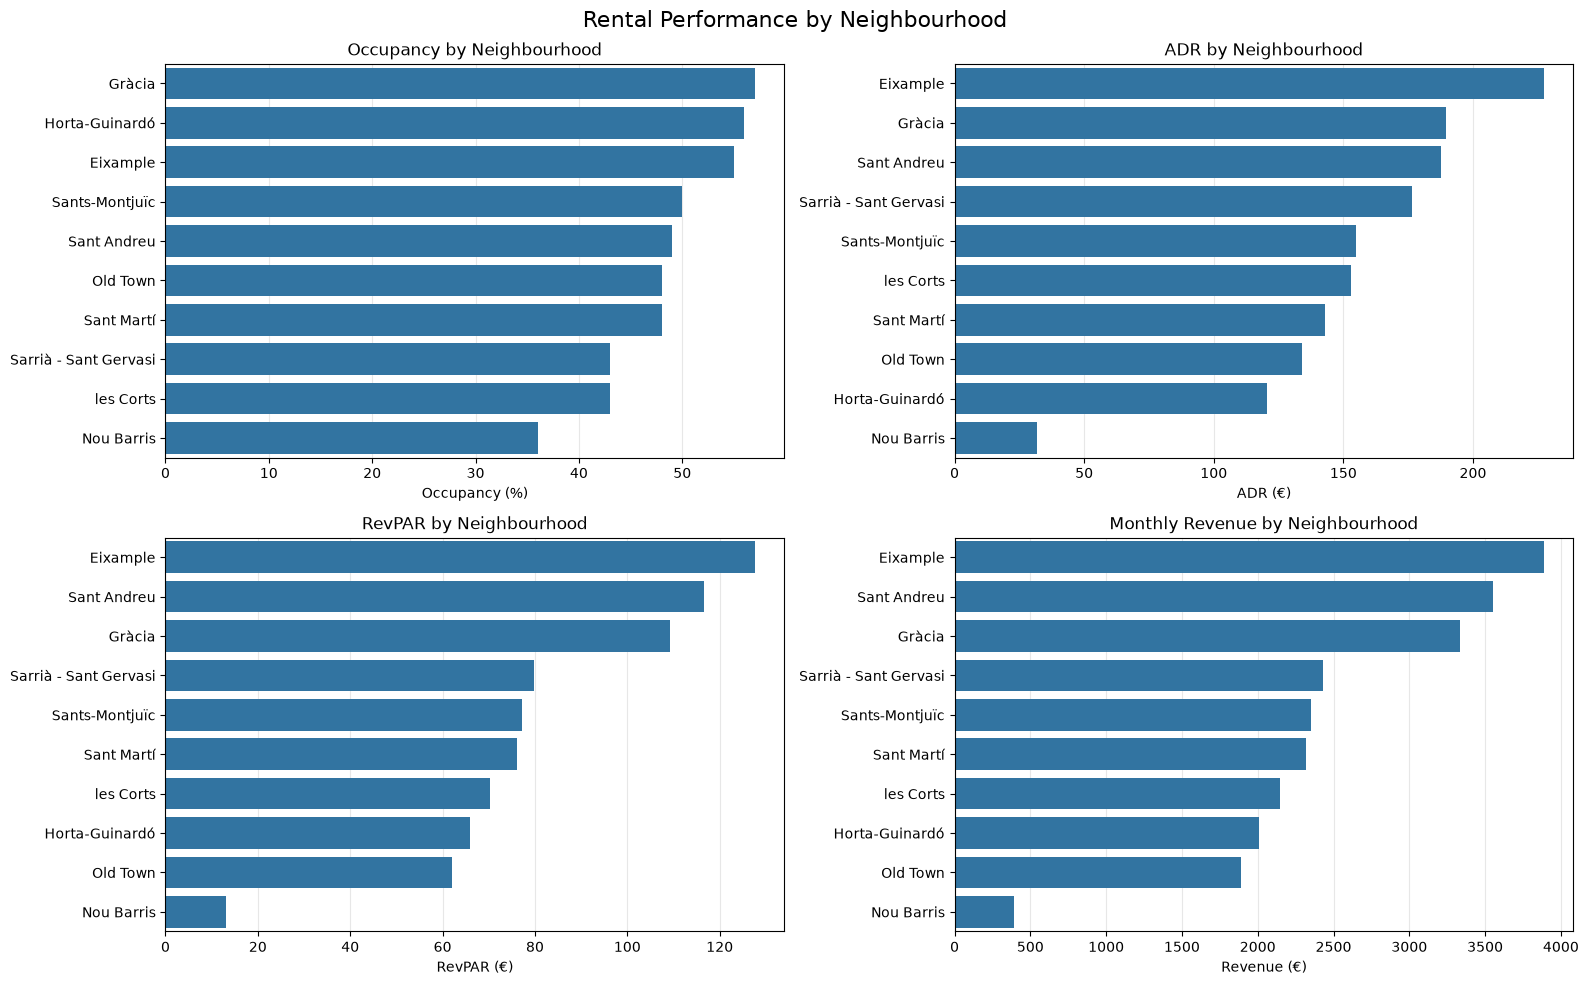

<Figure size 640x480 with 0 Axes>

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Occupancy
sns.barplot(
    data=plot_data.sort_values("occupancy_pct", ascending=False),
    x="occupancy_pct",
    y="neighborhood",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Occupancy by Neighbourhood")
axes[0, 0].set_xlabel("Occupancy (%)")
axes[0, 0].set_ylabel("")

# ADR
sns.barplot(
    data=plot_data.sort_values("avg_daily_rate", ascending=False),
    x="avg_daily_rate",
    y="neighborhood",
    ax=axes[0, 1]
)
axes[0, 1].set_title("ADR by Neighbourhood")
axes[0, 1].set_xlabel("ADR (€)")
axes[0, 1].set_ylabel("")

# RevPAR
sns.barplot(
    data=plot_data.sort_values("revpar", ascending=False),
    x="revpar",
    y="neighborhood",
    ax=axes[1, 0]
)
axes[1, 0].set_title("RevPAR by Neighbourhood")
axes[1, 0].set_xlabel("RevPAR (€)")
axes[1, 0].set_ylabel("")

# Revenue
sns.barplot(
    data=plot_data.sort_values("revenue", ascending=False),
    x="revenue",
    y="neighborhood",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Monthly Revenue by Neighbourhood")
axes[1, 1].set_xlabel("Revenue (€)")
axes[1, 1].set_ylabel("")

plt.suptitle("Rental Performance by Neighbourhood", fontsize=16)

for ax in axes.flat:
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

plt.tight_layout()

plt.show()

##### Neighbourhood matters: Eixample leads in financial performance, Gràcia in occupancy, while Nou Barris consistently underperforms.

### 2: Is there a relationship between distance to metro stations and rental performance?

In [87]:
# Prepare unique listings and metro stations for distance analysis 

listings = (
    df[["listing_id", "latitude", "longitude"]]
    .drop_duplicates(subset="listing_id")
    .copy()
)

metro = poi[poi["category"] == "metro"].copy()

print(listings.shape)
print(metro.shape)

(968, 3)
(174, 4)


#### function that calculates distance (AI)

In [88]:
from math import radians, sin, cos, sqrt, atan2

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [89]:
# for each listing, calculate the distance to each metro station and find the minimum distance (whcih is the nearest metro station)

nearest_metro_distances = []

for _, listing in listings.iterrows():

    distances = []

    for _, station in metro.iterrows():

        distance = calculate_distance(
            listing["latitude"],
            listing["longitude"],
            station["latitude"],
            station["longitude"]
        )

        distances.append(distance)

# taking the minimum distance for each listing (nearest metro station)
    nearest_metro_distances.append(min(distances))

In [90]:
listings["metro_distance_km"] = nearest_metro_distances

In [91]:
listings["metro_distance_km"] = listings["metro_distance_km"].round(3)

In [92]:
listings.head(10)

,listing_id,latitude,longitude,metro_distance_km
2,14948804,41.406980,2.182410,0.014
44,1175393002332902164,41.399890,2.184710,0.349
63,3110443,41.391860,2.171500,0.355
138,3491453,41.408900,2.172700,0.341
210,19764608,41.401200,2.170940,0.243
217,36833589,41.373350,2.169980,0.187
274,1088965887935366226,41.379548,2.167159,0.326
292,52727837,41.397590,2.158920,0.201
314,838133377354880685,41.371400,2.144700,0.440
336,29048134,41.411514,2.179317,0.291


In [93]:
# Add nearest metro distance to the main dataset (by listing_id)

df = df.merge(
    listings[["listing_id", "metro_distance_km"]],
    on="listing_id",
    how="left"
)

In [94]:
df[["listing_id", "metro_distance_km"]].head()

,listing_id,metro_distance_km
0,14948804,0.014
1,14948804,0.014
2,14948804,0.014
3,14948804,0.014
4,14948804,0.014


In [95]:
df["metro_distance_km"].describe()

count    26915.000000
mean         0.285015
std          0.166612
min          0.011000
25%          0.188000
50%          0.269000
75%          0.353000
max          3.754000
Name: metro_distance_km, dtype: float64

#### Final table, distance to metro (corr almost 0 = no depandance between distance to metro and financial metrics)

In [96]:
metro_corr = df[
    [
        "metro_distance_km",
        "occupancy",
        "avg_daily_rate",
        "revpar",
        "revenue"
    ]
].corr()

metro_corr

,metro_distance_km,occupancy,avg_daily_rate,revpar,revenue
metro_distance_km,1.000000,-0.047302,-0.078904,-0.080169,-0.080013
occupancy,-0.047302,1.000000,0.042701,0.535600,0.535055
avg_daily_rate,-0.078904,0.042701,1.000000,0.662502,0.662214
revpar,-0.080169,0.535600,0.662502,1.000000,0.999611
revenue,-0.080013,0.535055,0.662214,0.999611,1.000000


##### Visualisation

In [97]:
metro_corr_plot = (
    metro_corr["metro_distance_km"]
    .drop("metro_distance_km")
    .reset_index()
)

metro_corr_plot.columns = ["metric", "correlation"]

metro_corr_plot

,metric,correlation
0,occupancy,-0.047302
1,avg_daily_rate,-0.078904
2,revpar,-0.080169
3,revenue,-0.080013


In [98]:
metro_corr_plot["strength"] = metro_corr_plot["correlation"].abs()

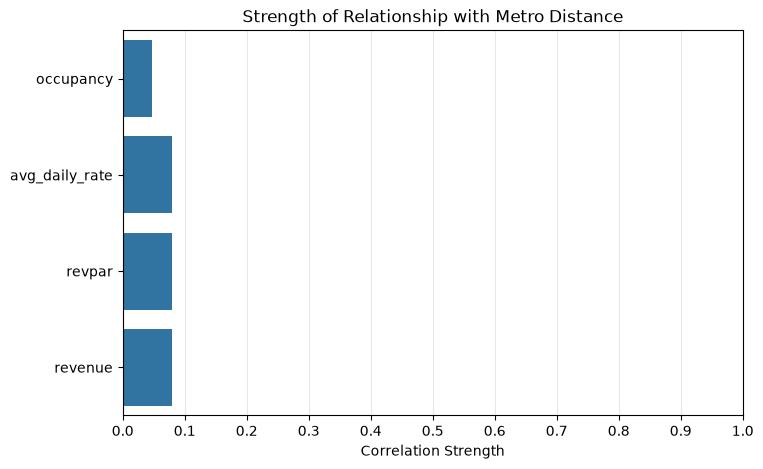

In [99]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=metro_corr_plot,
    x="strength",
    y="metric"
)

plt.xlim(0, 1.0)
plt.xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

plt.title("Strength of Relationship with Metro Distance")
plt.xlabel("Correlation Strength")
plt.ylabel("")

plt.grid(axis="x", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.show()

##### Metro proximity has a very weak relationship with rental performance. Correlation strength is only about 0.05–0.08 across Occupancy, ADR, RevPAR and Revenue.

#### 3: Is there a relationship between the number of tourist attractions within walking distance and rental performance?

In [100]:
# Filter tourist attractions

attractions = poi[poi["category"] == "attraction"].copy()

attractions.shape

(721, 4)

In [101]:
# the same function as I did for metro distance, but takes all the atractions in 1km radious (AI)

attractions_1km = []

for _, listing in listings.iterrows():

    count = 0

# function to calculate distance
    for _, attraction in attractions.iterrows():

        distance = calculate_distance(
            listing["latitude"],
            listing["longitude"],
            attraction["latitude"],
            attraction["longitude"]
        )
# limitimg to 1km
        if distance <= 1:
            count += 1

    attractions_1km.append(count)

In [102]:
# Add the number of attractions within 1 km to each listing

listings["attractions_1km"] = attractions_1km

listings[
    ["listing_id", "attractions_1km"]
].head()

,listing_id,attractions_1km
2,14948804,20
44,1175393002332902164,26
63,3110443,99
138,3491453,18
210,19764608,30


In [103]:
listings["attractions_1km"].describe()

count    968.000000
mean      56.559917
std       46.507925
min        0.000000
25%       19.000000
50%       35.000000
75%       94.000000
max      159.000000
Name: attractions_1km, dtype: float64

In [104]:
# Adding attraction density within 1 km to the main dataset

df = df.merge(
    listings[["listing_id", "attractions_1km"]],
    on="listing_id",
    how="left"
)

In [105]:
df[["listing_id", "attractions_1km"]].head()

,listing_id,attractions_1km
0,14948804,20
1,14948804,20
2,14948804,20
3,14948804,20
4,14948804,20


In [106]:
# checking correlation between attraction density and rental performance metrics

attraction_corr = df[
    [
        "attractions_1km",
        "occupancy",
        "avg_daily_rate",
        "revpar",
        "revenue"
    ]
].corr()

attraction_corr["attractions_1km"]

attractions_1km    1.000000
occupancy         -0.003027
avg_daily_rate     0.005813
revpar            -0.012900
revenue           -0.012838
Name: attractions_1km, dtype: float64

In [107]:
listings["attractions_1km"].describe()

count    968.000000
mean      56.559917
std       46.507925
min        0.000000
25%       19.000000
50%       35.000000
75%       94.000000
max      159.000000
Name: attractions_1km, dtype: float64

##### Visualisation

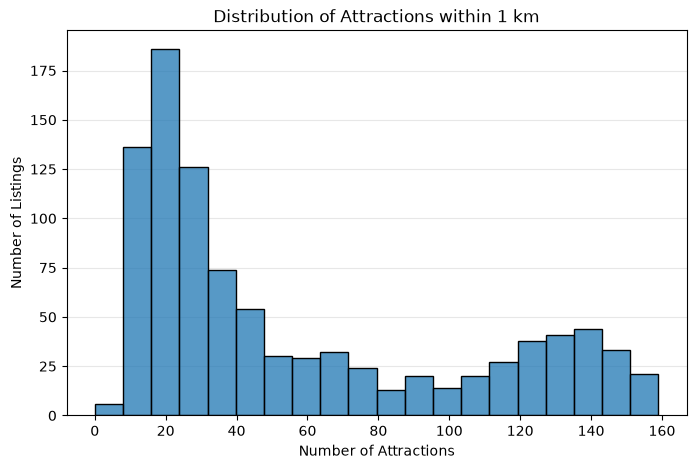

In [108]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=listings,
    x="attractions_1km",
    bins=20
)

plt.title("Distribution of Attractions within 1 km")
plt.xlabel("Number of Attractions")
plt.ylabel("Number of Listings")

plt.grid(axis="y", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.show()

In [109]:
attraction_corr_plot = (
    attraction_corr["attractions_1km"]
    .drop("attractions_1km")
    .reset_index()
)

attraction_corr_plot.columns = ["metric", "correlation"]

attraction_corr_plot["strength"] = (
    attraction_corr_plot["correlation"].abs()
)

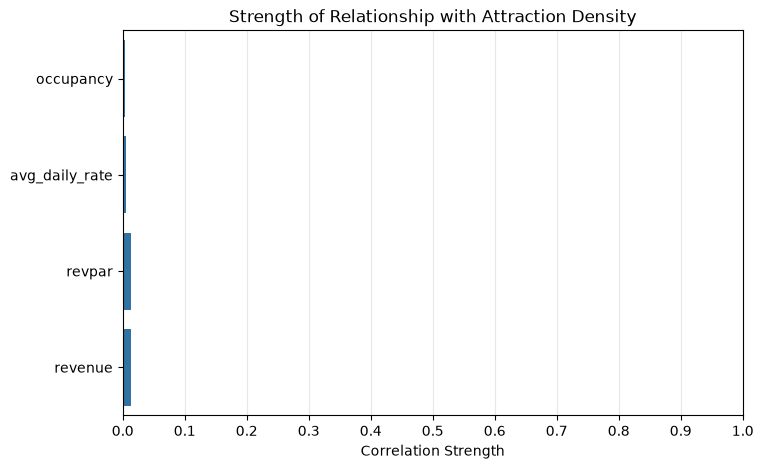

In [110]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=attraction_corr_plot,
    x="strength",
    y="metric"
)

plt.xlim(0, 1.0)

plt.xticks([
    0.0, 0.1, 0.2, 0.3, 0.4,
    0.5, 0.6, 0.7, 0.8, 0.9, 1.0
])

plt.title("Strength of Relationship with Attraction Density")
plt.xlabel("Correlation Strength")
plt.ylabel("")

plt.grid(axis="x", alpha=0.3)
plt.gca().set_axisbelow(True)

plt.show()

##### The number of tourist attractions within 1 km shows almost no relationship with rental performance. Correlation strength is close to zero across Occupancy, ADR, RevPAR, and Revenue.
##### Attraction density → practically no relationship with performance.

#### 4: What matters more for rental performance: the neighbourhood itself or proximity to POIs?

In [111]:
# Compare the best and worst neighbourhood performance for each metric

neighborhood_gap = pd.DataFrame({
    "metric": ["Occupancy", "ADR", "RevPAR", "Revenue"],
    
    "best": [
        neighborhood_valid["occupancy"].max(),
        neighborhood_valid["avg_daily_rate"].max(),
        neighborhood_valid["revpar"].max(),
        neighborhood_valid["revenue"].max()
    ],
    
    "worst": [
        neighborhood_valid["occupancy"].min(),
        neighborhood_valid["avg_daily_rate"].min(),
        neighborhood_valid["revpar"].min(),
        neighborhood_valid["revenue"].min()
    ]
})

neighborhood_gap

,metric,best,worst
0,Occupancy,0.57,0.36
1,ADR,227.29,31.77
2,RevPAR,127.56,13.00
3,Revenue,3886.67,395.35


In [112]:
# Calculating the percentage gap between the best and worst neighbourhood

neighborhood_gap["difference_pct"] = (
    (neighborhood_gap["best"] - neighborhood_gap["worst"])
    / neighborhood_gap["worst"]
    * 100
).round(1)

neighborhood_gap

,metric,best,worst,difference_pct
0,Occupancy,0.57,0.36,58.3
1,ADR,227.29,31.77,615.4
2,RevPAR,127.56,13.00,881.2
3,Revenue,3886.67,395.35,883.1


##### Final visualisation

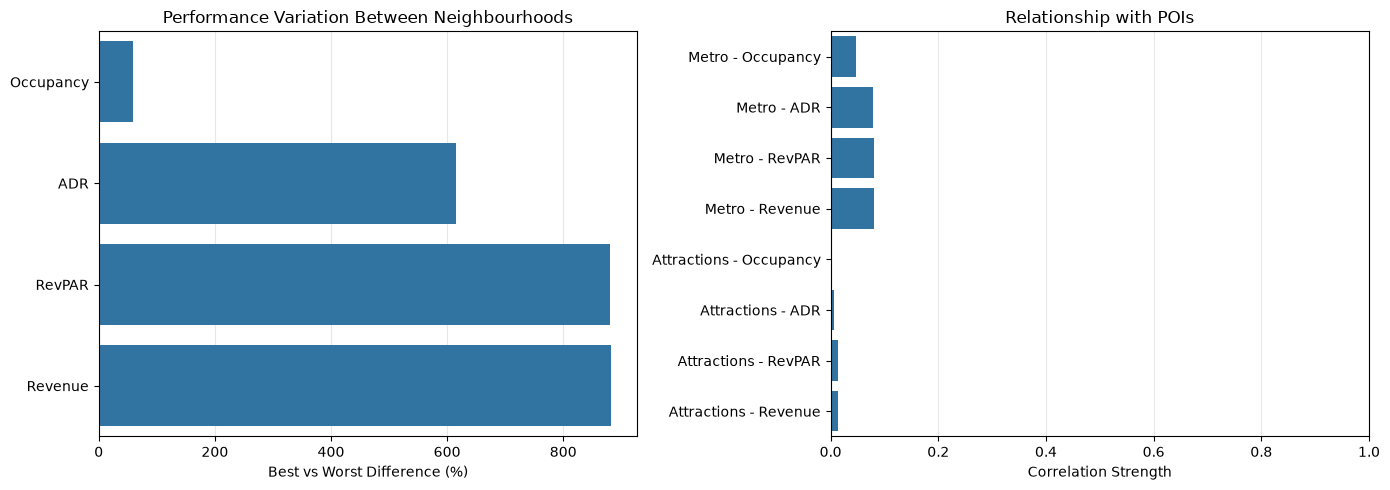

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Neighbourhood differences
sns.barplot(
    data=neighborhood_gap,
    x="difference_pct",
    y="metric",
    ax=axes[0]
)

axes[0].set_title("Performance Variation Between Neighbourhoods")
axes[0].set_xlabel("Best vs Worst Difference (%)")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.3)
axes[0].set_axisbelow(True)


# 2. POI correlations
poi_strength = pd.DataFrame({
    "factor": [
        "Metro - Occupancy",
        "Metro - ADR",
        "Metro - RevPAR",
        "Metro - Revenue",
        "Attractions - Occupancy",
        "Attractions - ADR",
        "Attractions - RevPAR",
        "Attractions - Revenue"
    ],
    
    "strength": [
        0.047,
        0.079,
        0.080,
        0.080,
        0.003,
        0.006,
        0.013,
        0.013
    ]
})

sns.barplot(
    data=poi_strength,
    x="strength",
    y="factor",
    ax=axes[1]
)

axes[1].set_xlim(0, 1)
axes[1].set_title("Relationship with POIs")
axes[1].set_xlabel("Correlation Strength")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.3)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

### H1 — PARTLY SUPPORTED.

Rental performance does vary substantially by neighbourhood, but proximity to metro stations and tourist attractions shows little to no relationship with performance.
- Neighbourhood: clearly associated with performance differences. Eixample leads in ADR, RevPAR and Revenue, while Gràcia has the highest occupancy. Nou Barris performs weakest across all four metrics.
- Metro proximity: very weak relationship. Correlation strength with Occupancy, ADR, RevPAR and Revenue is only about 0.05–0.08.
- Tourist attractions: practically no relationship. The number of attractions within 1 km has correlations of only about 0.00–0.01 with the performance metrics.
- Overall: the neighbourhood itself shows a much stronger relationship with rental performance than proximity to POIs.

##### Final takeaway
Location matters, but mainly at the neighbourhood level. In this dataset, being closer to metro stations or surrounded by more tourist attractions does not meaningfully improve rental performance.
